In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
customers = pd.read_csv('sample_data/olist_customers_dataset.csv')
geolocation = pd.read_csv('sample_data/olist_geolocation_dataset.csv')
orders = pd.read_csv('sample_data/olist_orders_dataset.csv')
order_items = pd.read_csv('sample_data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('sample_data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('sample_data/olist_order_reviews_dataset.csv')
products = pd.read_csv('sample_data/olist_products_dataset.csv')
sellers = pd.read_csv('sample_data/olist_sellers_dataset.csv')
product_category_names = pd.read_csv('sample_data/product_category_name_translation.csv')

In [ ]:
print(f"\n📁 CUSTOMERS ({customers.shape[0]} записей, {customers.shape[1]} колонок):")
print(customers.columns.tolist())

print(f"\n📁 GEOLOCATION ({geolocation.shape[0]} записей, {geolocation.shape[1]} колонок):")
print(geolocation.columns.tolist())

print(f"\n📁 ORDERS ({orders.shape[0]} записей, {orders.shape[1]} колонок):")
print(orders.columns.tolist())

print(f"\n📁 ORDER_ITEMS ({order_items.shape[0]} записей, {order_items.shape[1]} колонок):")
print(order_items.columns.tolist())

print(f"\n📁 ORDER_PAYMENTS ({order_payments.shape[0]} записей, {order_payments.shape[1]} колонок):")
print(order_payments.columns.tolist())

print(f"\n📁 ORDER_REVIEWS ({order_reviews.shape[0]} записей, {order_reviews.shape[1]} колонок):")
print(order_reviews.columns.tolist())

print(f"\n📁 PRODUCTS ({products.shape[0]} записей, {products.shape[1]} колонок):")
print(products.columns.tolist())

print(f"\n📁 SELLERS ({sellers.shape[0]} записей, {sellers.shape[1]} колонок):")
print(sellers.columns.tolist())

print(f"\n📁 PRODUCT_CATEGORY_NAMES ({product_category_names.shape[0]} записей, {product_category_names.shape[1]} колонок):")
print(product_category_names.columns.tolist())



📁 CUSTOMERS (99441 записей, 5 колонок):
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

📁 GEOLOCATION (1000163 записей, 5 колонок):
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

📁 ORDERS (99441 записей, 8 колонок):
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

📁 ORDER_ITEMS (112650 записей, 7 колонок):
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

📁 ORDER_PAYMENTS (103886 записей, 5 колонок):
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

📁 ORDER_REVIEWS (99224 записей, 7 колонок):
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestam

In [ ]:
print("="*60)
print("📋 ORDERS (Заказы)")
print("="*60)
print(orders.head())

print("\n" + "="*60)
print("📦 ORDER_ITEMS (Элементы заказов)")
print("="*60)
print(order_items.head())

print("\n" + "="*60)
print("💰 ORDER_PAYMENTS (Платежи)")
print("="*60)
print(order_payments.head())

📋 ORDERS (Заказы)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00

In [ ]:
order_items_full = order_items.merge(products, on='product_id', how='left')
order_items_full = order_items_full.merge(product_category_names, on='product_category_name', how='left')


In [ ]:

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = orders.merge(order_items, on='order_id', how='left')\
    .groupby('order_month')['price']\
    .sum()\
    .reset_index()

monthly_revenue.columns = ['month', 'revenue']

print("💰 Выручка по месяцам (GMV):")
print(monthly_revenue)

💰 Выручка по месяцам (GMV):
      month     revenue
0   2016-09      267.36
1   2016-10    49507.66
2   2016-12       10.90
3   2017-01   120312.87
4   2017-02   247303.02
5   2017-03   374344.30
6   2017-04   359927.23
7   2017-05   506071.14
8   2017-06   433038.60
9   2017-07   498031.48
10  2017-08   573971.68
11  2017-09   624401.69
12  2017-10   664219.43
13  2017-11  1010271.37
14  2017-12   743914.17
15  2018-01   950030.36
16  2018-02   844178.71
17  2018-03   983213.44
18  2018-04   996647.75
19  2018-05   996517.68
20  2018-06   865124.31
21  2018-07   895507.22
22  2018-08   854686.33
23  2018-09      145.00
24  2018-10        0.00


#Удаляем месяцы, где revenue < 10000, так как они выглядят как шум или неполные записи

In [ ]:
monthly_revenue[monthly_revenue['revenue']>10000]

,month,revenue
1,2016-10,49507.66
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48
10,2017-08,573971.68
11,2017-09,624401.69


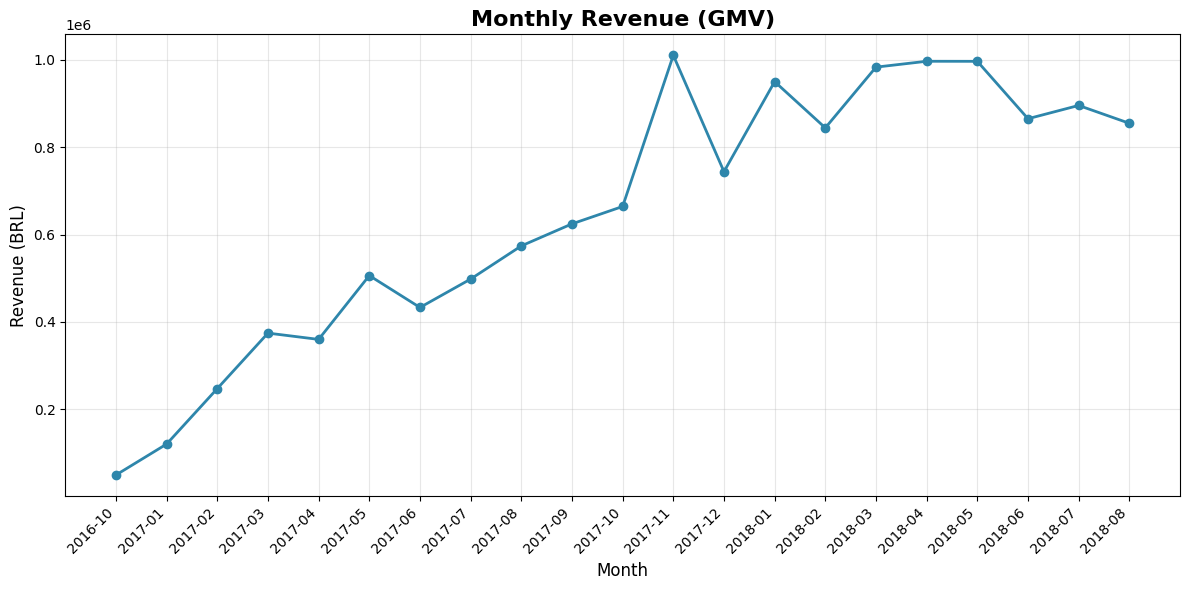

In [ ]:
monthly_revenue_clean = monthly_revenue[monthly_revenue['revenue']>10000]
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_clean['month'].astype(str),
    monthly_revenue_clean['revenue'],
    marker='o',
    linewidth=2,
    color='#2E86AB'
)

plt.title('Monthly Revenue (GMV)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (BRL)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

#Что случилось в декабре 2017, почему такой спад? Посмотрим, на чём в целом строится прибыль.

In [ ]:

order_items_full = order_items.merge(products, on='product_id', how='left')
order_items_full = order_items_full.merge(product_category_names, on='product_category_name', how='left')

order_items_full = order_items_full.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

order_items_full['order_month'] = order_items_full['order_purchase_timestamp'].dt.to_period('M')


months_to_compare = ['2017-11', '2017-12', '2018-01']
filtered_data = order_items_full[order_items_full['order_month'].astype(str).isin(months_to_compare)]

category_by_month = filtered_data.groupby(['order_month', 'product_category_name_english']).agg({
    'price': 'sum'
}).reset_index()

category_by_month.columns = ['month', 'category', 'revenue']

print("📊 Топ-10 категорий по месяцам:\n")
for month in months_to_compare:
    month_data = category_by_month[category_by_month['month'].astype(str) == month]
    month_data = month_data.sort_values('revenue', ascending=False).head(10)
    print(f"\n{month}:")
    print(month_data[['category', 'revenue']].to_string(index=False))

📊 Топ-10 категорий по месяцам:


2017-11:
             category  revenue
        watches_gifts 97724.57
       bed_bath_table 89412.54
        health_beauty 79120.40
computers_accessories 72656.00
       sports_leisure 64874.05
                 toys 64320.89
      furniture_decor 63223.97
           cool_stuff 56295.24
         garden_tools 45972.18
                 auto 34955.38

2017-12:
             category  revenue
        watches_gifts 71727.62
        health_beauty 61264.66
       sports_leisure 59792.66
                 toys 57194.14
       bed_bath_table 50505.85
                 auto 39287.64
           cool_stuff 39011.54
computers_accessories 37880.65
      furniture_decor 32011.75
            perfumery 27864.43

2018-01:
             category  revenue
       sports_leisure 91574.33
computers_accessories 83257.45
       bed_bath_table 76377.79
        watches_gifts 75621.24
        health_beauty 72470.49
      furniture_decor 55438.18
           stationery 41023.91
        

#Почему некоторые товары принесли ощутимо меньше прибыли после ноября?

In [ ]:

price_by_month = filtered_data.groupby(['order_month', 'product_category_name_english']).agg({
    'price': 'mean',
    'order_id': 'count'
}).reset_index()

price_by_month.columns = ['month', 'category', 'avg_price', 'num_orders']


top_nov_categories = category_by_month[category_by_month['month'].astype(str) == '2017-11']\
    .sort_values('revenue', ascending=False).head(5)['category'].tolist()


print("💰 Динамика средних цен (были ли скидки в ноябре?):\n")
for cat in top_nov_categories:
    cat_prices = price_by_month[price_by_month['category'] == cat]
    print(f"{cat}:")
    for _, row in cat_prices.iterrows():
        print(f"  {row['month']}: ср. цена {row['avg_price']:.2f} BRL, заказов: {int(row['num_orders'])}")
    print()

💰 Динамика средних цен (были ли скидки в ноябре?):

watches_gifts:
  2017-11: ср. цена 208.37 BRL, заказов: 469
  2017-12: ср. цена 195.44 BRL, заказов: 367
  2018-01: ср. цена 204.38 BRL, заказов: 370

bed_bath_table:
  2017-11: ср. цена 91.71 BRL, заказов: 975
  2017-12: ср. цена 91.50 BRL, заказов: 552
  2018-01: ср. цена 90.07 BRL, заказов: 848

health_beauty:
  2017-11: ср. цена 135.48 BRL, заказов: 584
  2017-12: ср. цена 131.47 BRL, заказов: 466
  2018-01: ср. цена 115.40 BRL, заказов: 628

computers_accessories:
  2017-11: ср. цена 136.57 BRL, заказов: 532
  2017-12: ср. цена 131.99 BRL, заказов: 287
  2018-01: ср. цена 117.76 BRL, заказов: 707

sports_leisure:
  2017-11: ср. цена 106.00 BRL, заказов: 612
  2017-12: ср. цена 121.28 BRL, заказов: 493
  2018-01: ср. цена 140.02 BRL, заказов: 654



#Цена поменялась не так сильно на те же watches_gift, но и количество ниже, поэтому тут потеря денег, хотя спрос всё ещё высокий. А вот на computers_accessories однозначно стоило сделать скидку ещё раньше. На sports_leisure можно было заработать ещё больше, график отразит, где теряется много денег.

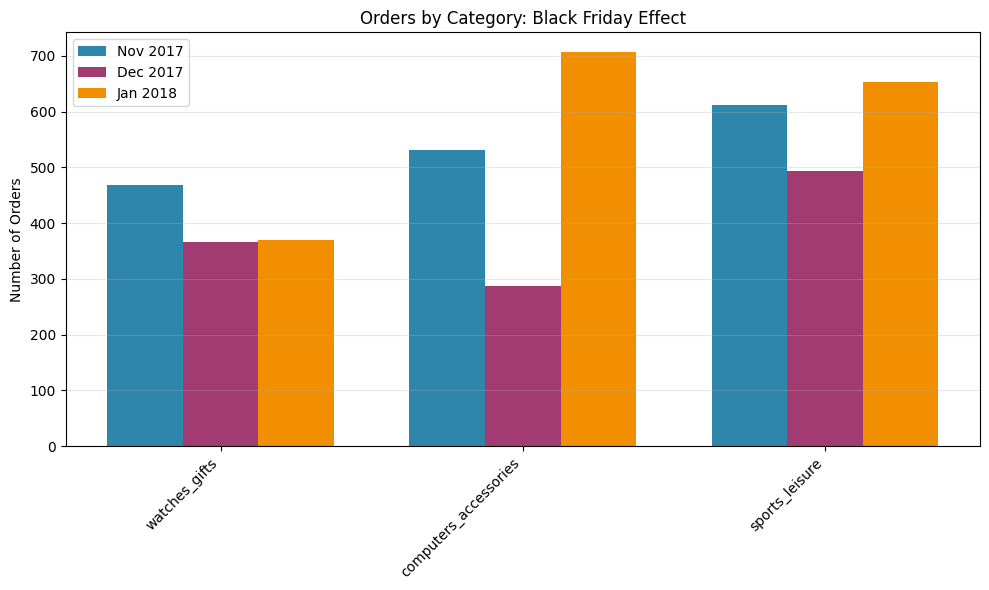

In [ ]:
import matplotlib.pyplot as plt

categories = ['watches_gifts', 'computers_accessories', 'sports_leisure']
nov_orders = [469, 532, 612]
dec_orders = [367, 287, 493]
jan_orders = [370, 707, 654]

x = range(len(categories))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], nov_orders, width, label='Nov 2017', color='#2E86AB')
plt.bar(x, dec_orders, width, label='Dec 2017', color='#A23B72')
plt.bar([i + width for i in x], jan_orders, width, label='Jan 2018', color='#F18F01')

plt.xticks(x, categories, rotation=45, ha='right')
plt.ylabel('Number of Orders')
plt.title('Orders by Category: Black Friday Effect')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#Что насчёт повторных заказов?

In [ ]:

df = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')


customer_orders = df.groupby('customer_unique_id')['order_id'].count().reset_index()
customer_orders.columns = ['customer_unique_id', 'order_count']


repeat_analysis = customer_orders.groupby('order_count').size().reset_index()
repeat_analysis.columns = ['orders_made', 'num_customers']


total_customers = repeat_analysis['num_customers'].sum()
repeat_analysis['percentage'] = (repeat_analysis['num_customers'] / total_customers * 100).round(1)

print("🔄 Повторные покупки клиентов:\n")
print(repeat_analysis.to_string(index=False))

one_time = repeat_analysis[repeat_analysis['orders_made'] == 1]['num_customers'].values[0]
repeat = total_customers - one_time

print(f"\n📊 Итого:")
print(f"• Одноразовые клиенты: {one_time} ({one_time/total_customers*100:.1f}%)")
print(f"• Повторные клиенты: {repeat} ({repeat/total_customers*100:.1f}%)")

🔄 Повторные покупки клиентов:

 orders_made  num_customers  percentage
           1          93099        96.9
           2           2745         2.9
           3            203         0.2
           4             30         0.0
           5              8         0.0
           6              6         0.0
           7              3         0.0
           9              1         0.0
          17              1         0.0

📊 Итого:
• Одноразовые клиенты: 93099 (96.9%)
• Повторные клиенты: 2997 (3.1%)


#В основном все клиенты одноразовые? Много ли мы теряем на этом?  Конверсия повторных покупок очень уж низкая...

In [ ]:



revenue = (orders
           .merge(order_payments[['order_id', 'payment_value']], on='order_id')
           .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
           .groupby('customer_unique_id')['payment_value']
           .sum()
           .reset_index()
           .rename(columns={'payment_value': 'total_spent'}))
# Сравниваем одноразовых и повторных
revenue_merged = revenue.merge(order_counts, on='customer_unique_id')
revenue_merged['customer_type'] = revenue_merged['order_count'].apply(lambda x: 'repeat' if x >= 2 else 'one-time')

summary = revenue_merged.groupby('customer_type').agg({
    'customer_unique_id': 'count',
    'total_spent': ['sum', 'mean', 'median']
}).round(2)

print("💵 Финансовый вклад:")
print(summary)

💵 Финансовый вклад:
              customer_unique_id  total_spent                
                           count          sum    mean  median
customer_type                                                
one-time                   93098  15064849.41  161.82  105.70
repeat                      2997    944022.71  314.99  225.84


#Количество повторных клентов в 30 раз меньше, а денег они принесли лишь в 18 раз меньше, так сколько мы потенциально теряем?

📊 Фактическая выручка: R$ 16,008,872
💸 Потенциально упущено: R$ 14,548,046
📈 Это +90.9% к выручке!


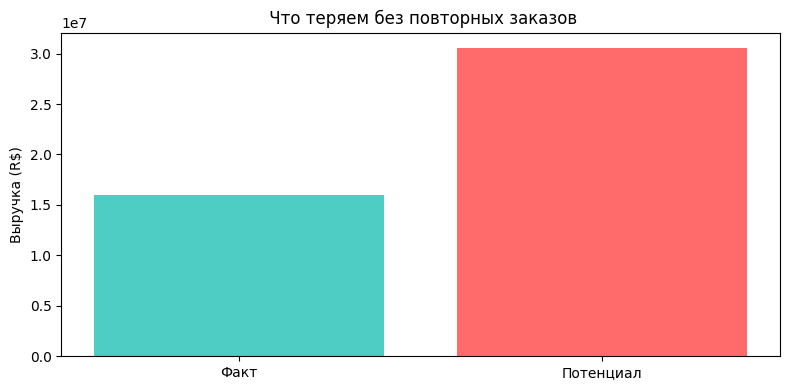

In [ ]:
df = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
df = df.merge(order_payments[['order_id', 'payment_value']], on='order_id')

stats = df.groupby('customer_unique_id').agg({'order_id': 'count', 'payment_value': 'sum'}).reset_index()
stats.columns = ['id', 'orders', 'spent']


one_time = stats[stats['orders'] == 1]
repeat = stats[stats['orders'] >= 2]

avg_order = df.groupby('order_id')['payment_value'].sum().mean()
potential_extra = len(one_time) * avg_order

print(f"📊 Фактическая выручка: R$ {stats['spent'].sum():,.0f}")
print(f"💸 Потенциально упущено: R$ {potential_extra:,.0f}")
print(f"📈 Это +{potential_extra/stats['spent'].sum()*100:.1f}% к выручке!")


plt.figure(figsize=(8, 4))
plt.bar(['Факт', 'Потенциал'],
        [stats['spent'].sum(), stats['spent'].sum() + potential_extra],
        color=['#4ECDC4', '#FF6B6B'])
plt.ylabel('Выручка (R$)')
plt.title(' Что теряем без повторных заказов')
plt.tight_layout()
plt.show()

#Потери ощутимы, нужно придумывать какие-то поощрения в виде скидок/бонусов/товаров в подарок за повторный заказ. Есть возможность существенно увеличить прибыль.

#ВЫВОД

#В ходе анализа данных интернет-магазина были изучены основные метрики: динамика выручки, распределение заказов и поведение пользователей.
#Было выявлено, что значительная часть выручки формируется за счёт небольшой доли пользователей, совершающих повторные покупки. При этом доля таких пользователей относительно невысока, что указывает на потенциальную точку роста — повышение retention.

#Также наблюдаются различия в выручке и количестве заказов по категориям товаров, что может быть использовано для оптимизации ассортимента и маркетинговых усилий.

#Таким образом, ключевыми направлениями для роста являются:
#- увеличение доли повторных покупок (retention),
#- работа с наиболее прибыльными категориями,
#- улучшение пользовательского опыта для повышения конверсии.